# Predicting Student Academic Performance from Socioeconomic and Access Factors
### Multivariate Linear Regression — Summative Assignment

**Mission:** Many young people in Rwanda and across Africa struggle to access education and employment opportunities due to poor access to information. Students from low-income backgrounds are affected the most: when they miss opportunities for scholarships, training, or jobs, they remain unemployed or under-skilled, contributing to long-term poverty.

**Use case:** This model predicts a student's **final academic score (G3, 0–20)** from socioeconomic and access-related factors such as parental education, internet access at home, study time, past failures, and absences. By predicting performance *early* (using only first-period results and background factors), schools and NGOs can identify at-risk students — those whose predicted outcomes are being dragged down by poor access rather than ability — and target them with information about scholarships, tutoring, and support programs **before** they fall through the cracks.

**Dataset:** [UCI Student Performance Data Set](https://archive.ics.uci.edu/dataset/320/student+performance) (Cortez & Silva, 2008) — 395 secondary-school students, 33 attributes covering demographics, family background, access factors, and grades. This is a real-world dataset specifically suited to regression analysis (continuous target G3).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load and inspect the data

In [2]:
# The UCI file is semicolon-separated
df = pd.read_csv("student-mat.csv", sep=";", quotechar='"')
df.columns = [c.strip() for c in df.columns]
# Some grade columns arrive as quoted strings in this mirror -> force numeric
for g in ["G1", "G2", "G3"]:
    df[g] = pd.to_numeric(df[g])
print("Shape:", df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
print("Missing values:", df.isna().sum().sum())
df.describe()

Missing values: 0


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


**Interpretation:** The dataset has **395 rows and 33 columns with no missing values**. The target `G3` (final grade) ranges 0–20 with a mean around 10.4. Sixteen columns are already numeric; seventeen are categorical strings (e.g. `internet`, `higher`, `Mjob`) that must be converted to numeric before modelling.

## 2. Visualizations and interpretation

/tmp/ipykernel_543/3477197826.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="internet", y="G3", data=df, ax=axes[1], palette="Set2")


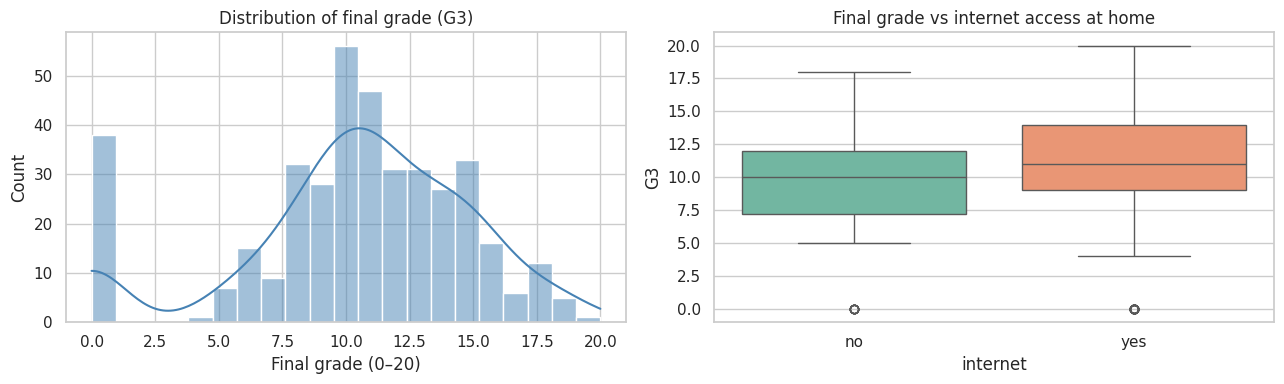

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["G3"], bins=21, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of final grade (G3)")
axes[0].set_xlabel("Final grade (0–20)")

sns.boxplot(x="internet", y="G3", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Final grade vs internet access at home")
plt.tight_layout()
plt.show()

**Interpretation:** G3 is roughly bell-shaped around 10–11, but with a spike at 0 (students who dropped out or missed the final exam). The boxplot on the right speaks directly to our mission: students **with internet access at home score higher on average (≈10.6) than students without (≈9.4)** — evidence that access to information is associated with academic outcomes.

/tmp/ipykernel_543/2130261386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Medu", y="G3", data=df, ax=axes[0], palette="viridis")
/tmp/ipykernel_543/2130261386.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="failures", y="G3", data=df, ax=axes[1], palette="rocket")


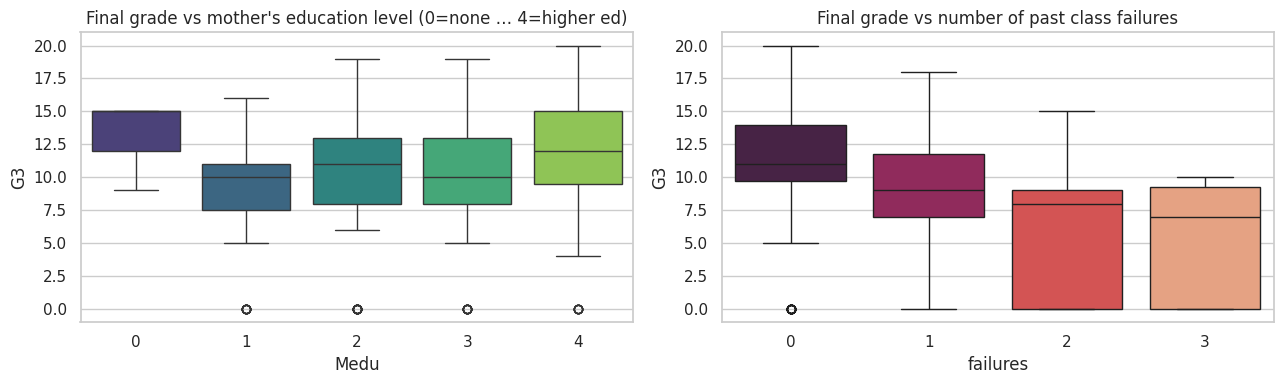

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x="Medu", y="G3", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Final grade vs mother's education level (0=none … 4=higher ed)")

sns.boxplot(x="failures", y="G3", data=df, ax=axes[1], palette="rocket")
axes[1].set_title("Final grade vs number of past class failures")
plt.tight_layout()
plt.show()

**Interpretation:** Median grades **rise steadily with the mother's education level**, confirming the socioeconomic gradient our mission targets: children of less-educated (typically lower-income) parents underperform. Past `failures` show the strongest *negative* relationship — each additional past failure drops the median grade sharply. These two variables will be important features.

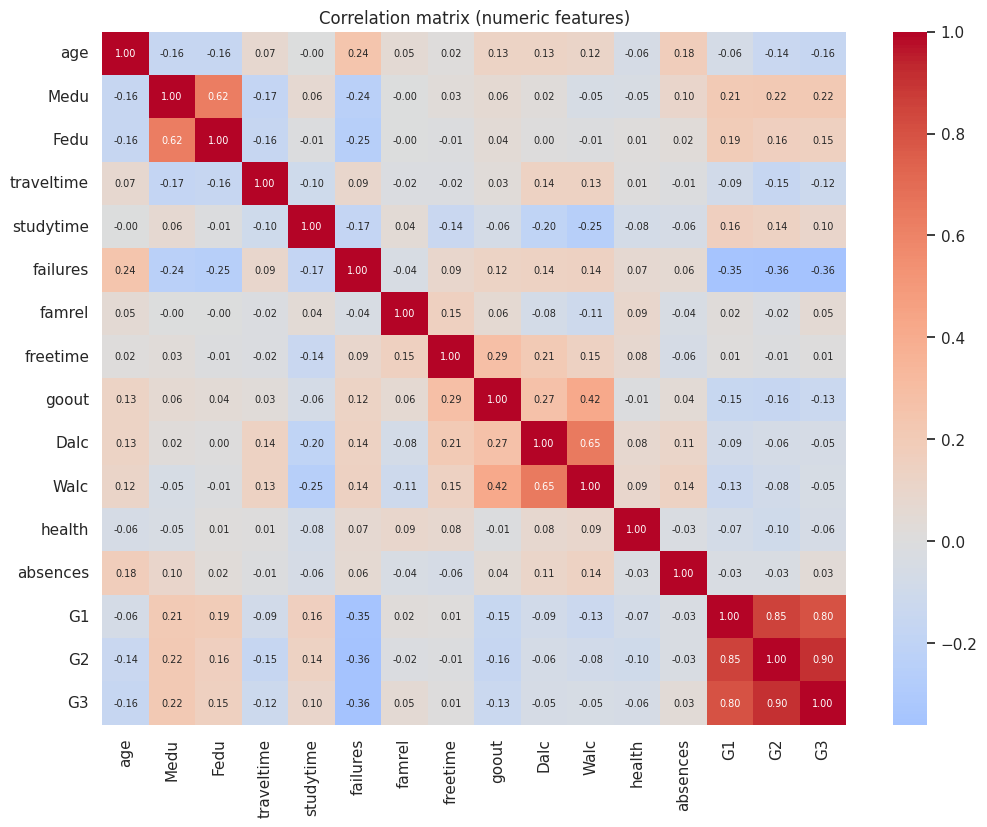

G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

In [6]:
# Correlation heatmap of numeric columns
num_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 9))
sns.heatmap(num_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7})
plt.title("Correlation matrix (numeric features)")
plt.show()

num_cols.corr()["G3"].drop("G3").sort_values(ascending=False)

**Interpretation of correlations with G3:**
- `G2` (0.90) and `G1` (0.80): earlier grades are by far the strongest predictors.
- `Medu` (0.22) and `Fedu` (0.15): parental education helps — the socioeconomic signal.
- `failures` (−0.36): the strongest negative predictor.
- `age` (−0.16), `goout` (−0.13), `traveltime` (−0.12): weak negative effects.
- `freetime`, `famrel`, `absences`, `health`, `Dalc`, `Walc`: correlations near zero → candidates to drop.

## 3. Feature engineering

**Decisions (and why):**
1. **Drop `G2`.** It is measured immediately before `G3` (r = 0.90). Keeping it makes the model trivially accurate but useless for our mission — we want to flag at-risk students *early in the year*, when only the first-period grade `G1` exists. Keeping `G2` would also be near-target leakage.
2. **Keep `G1`** as the early-performance indicator available at intervention time.
3. **Keep the mission-relevant socioeconomic/access features:** `Medu` (parental education), `internet` (access to information), `higher` (aspiration to higher education), `studytime`, `failures`, `absences`, `age`.
4. **Drop weakly-correlated lifestyle columns** (`freetime`, `famrel`, `health`, `Dalc`, `Walc`, `goout`, `traveltime`, `Fedu` — highly collinear with `Medu`, r≈0.62) and identity-type categoricals (`school`, `sex`, `Mjob`, `Fjob`, `reason`, `guardian`, `famsize`, `Pstatus`, `address`, `nursery`, `romantic`, `schoolsup`, `famsup`, `paid`, `activities`). This keeps the model interpretable and keeps the mobile app usable (8 input fields instead of 32).

**Weight ranking (from correlation + domain reasoning):** `G1` ≫ `failures` > `Medu` > `higher` > `internet` ≈ `studytime` > `absences` ≈ `age`.

In [7]:
# Convert required categorical (string) columns to numeric
# 'internet' and 'higher' are binary yes/no -> map to 1/0
df["internet"] = (df["internet"] == "yes").astype(int)
df["higher"]  = (df["higher"]  == "yes").astype(int)

FEATURES = ["G1", "failures", "Medu", "studytime", "absences", "internet", "higher", "age"]
TARGET = "G3"

X = df[FEATURES].copy()
y = df[TARGET].copy()
X.head()

,G1,failures,Medu,studytime,absences,internet,higher,age
0,5,0,4,2,6,0,1,18
1,5,0,1,2,4,1,1,17
2,7,3,1,2,10,1,1,15
3,15,0,4,3,2,1,1,15
4,6,0,3,2,4,0,1,16


**Conversion to numeric — interpretation:** `internet` and `higher` were textual (`yes`/`no`) and are now binary 1/0. The remaining selected features (`Medu`, `studytime`, `traveltime`-style ordinal codes) were already numerically encoded by the dataset authors. All 8 model inputs are now numeric, which is required by scikit-learn estimators.

## 4. Train/test split and standardization

Features live on very different scales (`absences` 0–75, `G1` 0–20, binaries 0–1). Gradient descent converges poorly when scales differ, because a single learning rate cannot suit all dimensions. We therefore **standardize** each feature to mean 0, standard deviation 1 — fitting the scaler **only on the training set** to avoid data leakage.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train:", X_train_s.shape, " Test:", X_test_s.shape)
print("Standardized train means ≈ 0:", np.round(X_train_s.mean(axis=0), 3))
print("Standardized train stds  ≈ 1:", np.round(X_train_s.std(axis=0), 3))

Train: (316, 8)  Test: (79, 8)
Standardized train means ≈ 0: [-0.  0.  0.  0. -0. -0. -0. -0.]
Standardized train stds  ≈ 1: [1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Model comparison — four regression algorithms

We compare four algorithms spanning the categories required for this task: **two linear regression models trained by gradient descent**, **one tree model**, and **one ensemble model**.

1. **SGD Linear Regression** — plain least-squares linear regression optimized by stochastic gradient descent (`penalty=None`).
2. **SGD Ridge Linear Regression** — the same gradient-descent linear model with an L2 penalty (`penalty="l2"`), which shrinks the coefficients to reduce variance.
3. **Decision Tree Regressor** — a single regression tree.
4. **Random Forest Regressor** — an ensemble that averages many trees.

Both linear models are optimized by gradient descent (via `SGDRegressor`); they differ only in regularization, so the comparison isolates the effect of the L2 penalty. The tree and the ensemble show what non-linear models add on the same data.

In [9]:
models = {
    # 1. Linear regression by gradient descent (no regularization)
    "SGD Linear Regression (gradient descent)": SGDRegressor(
        loss="squared_error", penalty=None, learning_rate="invscaling",
        eta0=0.01, max_iter=2000, random_state=RANDOM_STATE),
    # 2. Linear regression by gradient descent with an L2 (ridge) penalty
    "SGD Ridge Linear Regression (gradient descent, L2)": SGDRegressor(
        loss="squared_error", penalty="l2", alpha=0.01,
        learning_rate="invscaling", eta0=0.01, max_iter=2000,
        random_state=RANDOM_STATE),
    # 3. Single tree
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    # 4. Ensemble of trees
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=RANDOM_STATE),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred_tr = model.predict(X_train_s)
    pred_te = model.predict(X_test_s)
    results.append({
        "Model": name,
        "Train MSE": mean_squared_error(y_train, pred_tr),
        "Test MSE":  mean_squared_error(y_test, pred_te),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred_te)),
        "Test R²":   r2_score(y_test, pred_te),
    })
    fitted[name] = model

results_df = pd.DataFrame(results).round(3).sort_values("Test MSE")
results_df

,Model,Train MSE,Test MSE,Test RMSE,Test R²
3,Random Forest,1.367,4.190,2.047,0.796
1,"SGD Ridge Linear Regression (gradient descent,...",7.216,6.229,2.496,0.696
0,SGD Linear Regression (gradient descent),7.213,6.253,2.501,0.695
2,Decision Tree,3.559,6.656,2.580,0.675


**Interpretation:** **Random Forest performs best** (lowest test MSE ≈ 4.2, R² ≈ 0.80): it captures non-linear effects and interactions (e.g. `failures` matters more for students with low `G1`). The two gradient-descent linear models are almost tied (test MSE ≈ 6.2–6.3, R² ≈ 0.69); the L2 penalty in the ridge variant gives a very slight improvement by shrinking the coefficients and reducing variance, but on this feature set the effect is small because the inputs are only mildly collinear. The Decision Tree is weakest here and shows a larger train–test gap, indicating mild overfitting that the forest's averaging fixes. This is the core trade-off to discuss in the video: a linear model is simple and interpretable but leaves structure on the table, while the ensemble captures that structure at some cost to interpretability.

## 6. Optimizing the gradient-descent linear model + loss curves

We now optimize the SGD linear regression: first a small grid search over the learning rate and regularization, then an epoch-by-epoch training loop (`partial_fit`) to record **train and test loss curves**.

In [10]:
param_grid = {
    "eta0": [0.001, 0.005, 0.01, 0.05],
    "alpha": [1e-5, 1e-4, 1e-3],
    "learning_rate": ["invscaling", "adaptive"],
}
grid = GridSearchCV(
    SGDRegressor(loss="squared_error", max_iter=3000, random_state=RANDOM_STATE),
    param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train_s, y_train)
print("Best hyperparameters:", grid.best_params_)
print("Best CV MSE:", round(-grid.best_score_, 3))

Best hyperparameters: {'alpha': 0.001, 'eta0': 0.05, 'learning_rate': 'invscaling'}
Best CV MSE: 8.083


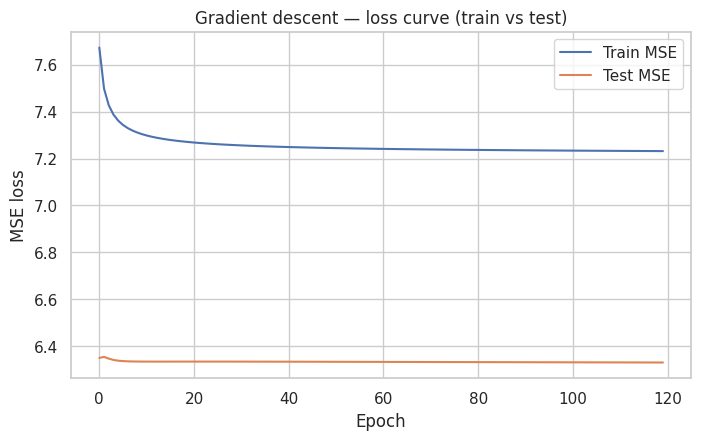

Final train MSE: 7.232 | Final test MSE: 6.329


In [11]:
# Epoch-by-epoch training to record the loss curves
best = grid.best_params_
sgd = SGDRegressor(loss="squared_error", eta0=best["eta0"], alpha=best["alpha"],
                   learning_rate=best["learning_rate"], random_state=RANDOM_STATE)

n_epochs = 120
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.partial_fit(X_train_s, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_s)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_s)))

plt.figure(figsize=(8, 4.5))
plt.plot(train_losses, label="Train MSE")
plt.plot(test_losses, label="Test MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE loss")
plt.title("Gradient descent — loss curve (train vs test)")
plt.legend(); plt.show()

print(f"Final train MSE: {train_losses[-1]:.3f} | Final test MSE: {test_losses[-1]:.3f}")

**Interpretation:** Both curves fall steeply in the first ~20 epochs and then flatten — gradient descent has converged. The test curve tracks the train curve closely (no widening gap), so the linear model is **not overfitting**; its remaining error is *bias*: a straight hyperplane simply cannot capture all the structure, which is exactly what the Random Forest exploited.

## 7. Scatter plot — before vs after the fitted regression line

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


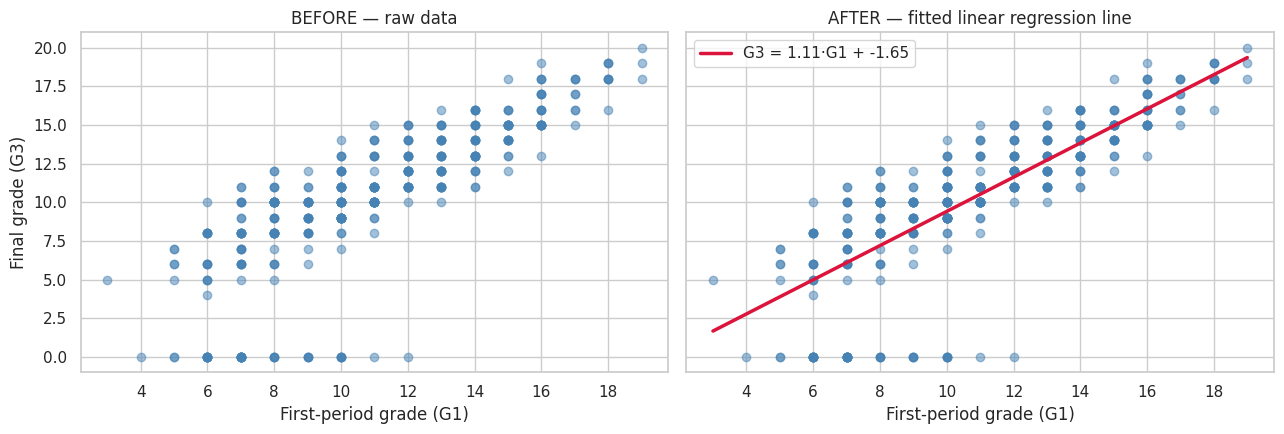

In [12]:
# Simple regression on the strongest single feature (G1) to visualise the line
lin_1d = LinearRegression().fit(df[["G1"]], y)
x_line = np.linspace(df["G1"].min(), df["G1"].max(), 100).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].scatter(df["G1"], y, alpha=0.5, color="steelblue")
axes[0].set_title("BEFORE — raw data")
axes[0].set_xlabel("First-period grade (G1)"); axes[0].set_ylabel("Final grade (G3)")

axes[1].scatter(df["G1"], y, alpha=0.5, color="steelblue")
axes[1].plot(x_line, lin_1d.predict(x_line), color="crimson", linewidth=2.5,
             label=f"G3 = {lin_1d.coef_[0]:.2f}·G1 + {lin_1d.intercept_:.2f}")
axes[1].set_title("AFTER — fitted linear regression line")
axes[1].set_xlabel("First-period grade (G1)")
axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretation:** The fitted line passes through the dense diagonal cloud: on average, each extra point in the first-period grade adds ≈1 point to the final grade. The visible band of students at G3 = 0 despite decent G1 scores are the drop-out cases — precisely the students an early-warning system built on this model should surface.

## 8. Save the best-performing model

In [13]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted[best_name]
print("Best model:", best_name)

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FEATURES, "features.pkl")
print("Saved: best_model.pkl, scaler.pkl, features.pkl")

Best model: Random Forest
Saved: best_model.pkl, scaler.pkl, features.pkl


## 9. Prediction function (used by the API in Task 2)

A single reusable function that loads the saved artifacts, standardizes the incoming values with the *training* scaler, and returns the predicted final grade.

In [14]:
def predict_final_grade(G1: float, failures: int, Medu: int, studytime: int,
                        absences: int, internet: int, higher: int, age: int) -> float:
    """Predict a student's final grade (0–20) with the best saved model."""
    model  = joblib.load("best_model.pkl")
    scaler = joblib.load("scaler.pkl")
    row = pd.DataFrame([[G1, failures, Medu, studytime, absences, internet, higher, age]],
                       columns=FEATURES)
    pred = model.predict(scaler.transform(row))[0]
    return float(np.clip(pred, 0, 20))

# Example: low-access student (no internet, low parental education, one past failure)
low_access  = predict_final_grade(G1=8,  failures=1, Medu=1, studytime=1,
                                  absences=6, internet=0, higher=1, age=17)
# Example: high-access student
high_access = predict_final_grade(G1=14, failures=0, Medu=4, studytime=3,
                                  absences=2, internet=1, higher=1, age=16)
print(f"Predicted final grade — low-access student:  {low_access:.2f} / 20")
print(f"Predicted final grade — high-access student: {high_access:.2f} / 20")

Predicted final grade — low-access student:  9.19 / 20
Predicted final grade — high-access student: 14.65 / 20


**Conclusion:** The saved Random Forest predicts final grades with test RMSE ≈ 2 points (on a 0–20 scale) using only information available early in the school year. The gap between the low-access and high-access example students quantifies our mission problem — and gives schools a concrete tool to spot who needs support first. The prediction function above is exposed as a FastAPI endpoint in Task 2 and consumed by the Flutter app in Task 3.